# Cs-137 attenuation analysis helper

This notebook wraps your single-spectrum workflow into one function:

- reads `.Spe`
- plots spectrum and candidate peaks
- chooses the **rightmost** candidate peak
- performs local Gaussian + linear fit (with same `fit_half_width=30`)
- reports net peak rate (counts/s)

In [8]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from analysis_evan import (
    read_spe,
    find_peak_candidates,
    fit_local_peak,
    peak_rate_from_fit,
    gaussian_plus_linear,
)

plt.rcParams["figure.figsize"] = (7.5, 4.5)
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["xtick.labelsize"] = 14
plt.rcParams["ytick.labelsize"] = 14
plt.rcParams["legend.fontsize"] = 14


def analyze_file(
    filename,
    *,
    data_dir="data",
    rebin_factor=4,
    min_bin=80,
    prominence=None,
    height=None,
    distance=20,
    max_peaks=10,
    fit_half_width=30,
    min_p_value=0.0,
    plot_pad_bins=8,
    show_plots=True,
):
    """
    Run full single-file analysis and return fitted peak/rate summary.

    Candidate policy: always use the rightmost detected peak candidate.
    """
    notebook_dir = Path.cwd()
    spe_path = notebook_dir / data_dir / filename

    sp = read_spe(str(spe_path), rebin_factor=rebin_factor)

    print("=" * 80)
    print(f"File: {filename}")
    print(f"Raw channels: {sp.n_channels_raw}")
    print(f"Rebin factor: {sp.rebin_factor}")
    print(f"Channels used: {len(sp.counts)}")
    print(f"Live time [s]: {sp.live_time_s}")
    print(f"Real time [s]: {sp.real_time_s}")

    if show_plots:
        plt.figure()
        plt.bar(sp.bins, sp.counts, width=1.0, color="#4C78A8")
        plt.xlabel("Bin (rebinned)")
        plt.ylabel("Counts")
        plt.tight_layout()
        plt.show()

    cands = find_peak_candidates(
        sp.bins,
        sp.counts,
        min_bin=min_bin,
        prominence=prominence,
        height=height,
        distance=distance,
        max_peaks=max_peaks,
    )

    if len(cands.candidate_bins) == 0:
        raise ValueError(f"No candidate peaks found for {filename}")

    print("Candidate peaks:")
    for i, (b, h, p) in enumerate(
        zip(cands.candidate_bins, cands.candidate_heights, cands.candidate_prominences)
    ):
        print(f"[{i}] bin={b:.1f}, height={h:.1f}, prominence={p:.1f}")

    if show_plots:
        mask = sp.bins >= min_bin
        bins_use = sp.bins[mask]
        counts_use = sp.counts[mask]

        plt.figure()
        plt.bar(bins_use, counts_use, width=1.0, color="#4C78A8")
        plt.plot(cands.candidate_bins, cands.candidate_heights, "o", color="#E45756", ms=8)
        for i, (xb, yb) in enumerate(zip(cands.candidate_bins, cands.candidate_heights)):
            plt.text(xb, yb + 0.02 * np.max(counts_use), str(i), ha="center", va="bottom")
        plt.xlabel("Bin")
        plt.ylabel("Counts")
        plt.tight_layout()
        plt.show()

    # Rightmost candidate policy
    candidate_idx = len(cands.candidate_bins) - 1
    candidate_bin = float(cands.candidate_bins[candidate_idx])

    fit = fit_local_peak(
        sp.bins,
        sp.counts,
        candidate_bin=candidate_bin,
        fit_half_width=fit_half_width,
        min_p_value=min_p_value,
    )

    left, right = fit.fit_range
    xfit = sp.bins[left : right + 1]
    yfit = sp.counts[left : right + 1]

    print(f"Selected candidate index (rightmost): {candidate_idx}")
    print(f"Candidate bin: {candidate_bin:.2f}")
    print(f"Fit success: {fit.success}")
    print(f"mu = {fit.fit_center:.3f} +/- {fit.fit_center_err:.3f} bins")
    print(f"sigma = {fit.sigma:.3f} +/- {fit.sigma_err:.3f} bins")
    print(f"chi2/ndof = {fit.chi2_val:.2f}/{fit.ndof}, p = {fit.p_value:.4f}")
    print(f"N_fit_points = {len(xfit)}")

    if show_plots:
        xdense = np.linspace(xfit.min(), xfit.max(), 500)
        ydense = gaussian_plus_linear(
            xdense,
            fit.amplitude,
            fit.fit_center,
            fit.sigma,
            fit.background_intercept,
            fit.background_slope,
        )

        plot_left = max(0, left - plot_pad_bins)
        plot_right = min(len(sp.bins) - 1, right + plot_pad_bins)
        xplot = sp.bins[plot_left : plot_right + 1]
        yplot = sp.counts[plot_left : plot_right + 1]

        plt.figure()
        plt.bar(xplot, yplot, width=1.0, color="#4C78A8", label="Data")
        plt.plot(xdense, ydense, color="#E45756", lw=2.5, label="Gaussian + linear fit")
        plt.axvline(
            fit.fit_center,
            color="#54A24B",
            ls="--",
            lw=2,
            label=f"mu = {fit.fit_center:.2f}",
        )
        plt.xlabel("Bin")
        plt.ylabel("Counts")
        textbox = (
            f"$\\chi^2$/ndof = {fit.chi2_val:.2f}/{fit.ndof}\n"
            f"$p$ = {fit.p_value:.4f}"
        )
        plt.text(
            0.98,
            0.95,
            textbox,
            transform=plt.gca().transAxes,
            ha="right",
            va="top",
            fontsize=13,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="black"),
        )
        plt.legend()
        plt.tight_layout()
        plt.show()

    rate, rate_err = peak_rate_from_fit(
        fit,
        live_time_s=sp.live_time_s,
        method="gaussian_area",
    )
    print(f"Peak rate = {rate:.6f} +/- {rate_err:.6f} counts/s")

    return {
        "filename": filename,
        "candidate_idx": candidate_idx,
        "candidate_bin": candidate_bin,
        "fit_center": fit.fit_center,
        "fit_center_err": fit.fit_center_err,
        "sigma": fit.sigma,
        "sigma_err": fit.sigma_err,
        "chi2": fit.chi2_val,
        "ndof": fit.ndof,
        "p_value": fit.p_value,
        "live_time_s": sp.live_time_s,
        "rate_cps": rate,
        "rate_err_cps": rate_err,
    }

File: 03-12-Cs-137-scatter-0deg-0absorb.Spe
Raw channels: 2048
Rebin factor: 4
Channels used: 512
Live time [s]: 203.0
Real time [s]: 207.0


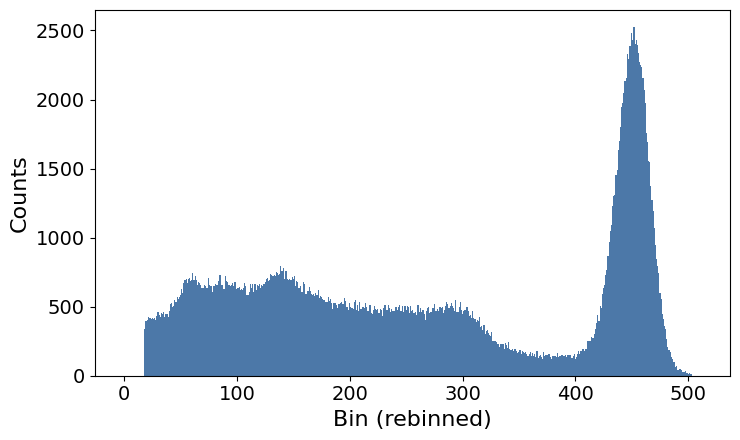

Candidate peaks:
[0] bin=85.0, height=731.0, prominence=80.0
[1] bin=139.0, height=798.0, prominence=216.0
[2] bin=231.0, height=515.0, prominence=82.0
[3] bin=260.0, height=514.0, prominence=77.0
[4] bin=294.0, height=545.0, prominence=145.0
[5] bin=452.0, height=2522.0, prominence=2401.0


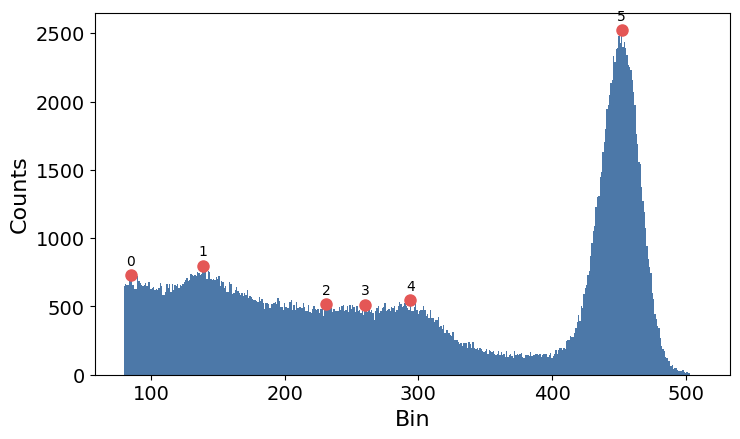

Selected candidate index (rightmost): 5
Candidate bin: 452.00
Fit success: True
mu = 451.976 +/- 0.108 bins
sigma = 14.304 +/- 0.171 bins
chi2/ndof = 57.95/56, p = 0.4031
N_fit_points = 61


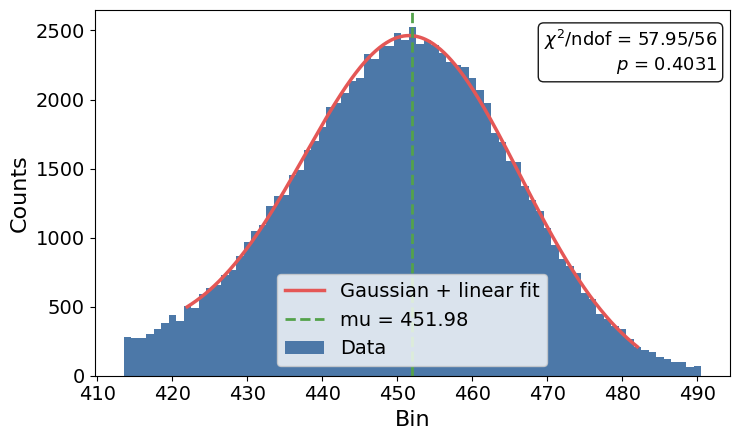

Peak rate = 418.627806 +/- 7.721911 counts/s
File: 03-12-Cs-137-scatter-0deg-1absorb.Spe
Raw channels: 2048
Rebin factor: 4
Channels used: 512
Live time [s]: 276.0
Real time [s]: 280.0


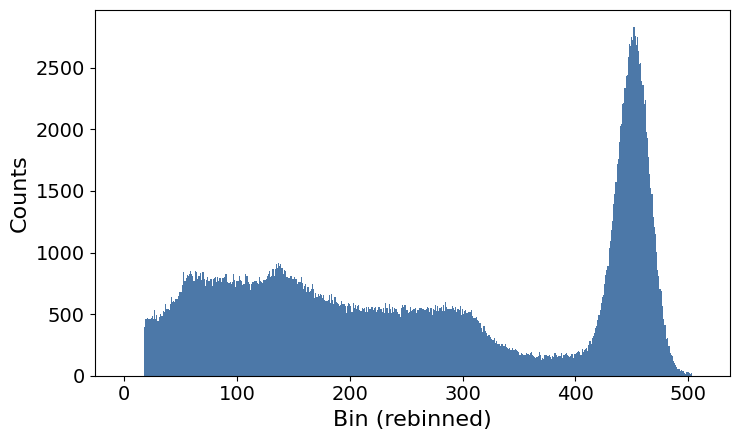

Candidate peaks:
[0] bin=108.0, height=827.0, prominence=109.0
[1] bin=137.0, height=915.0, prominence=218.0
[2] bin=285.0, height=596.0, prominence=116.0
[3] bin=452.0, height=2827.0, prominence=2696.0


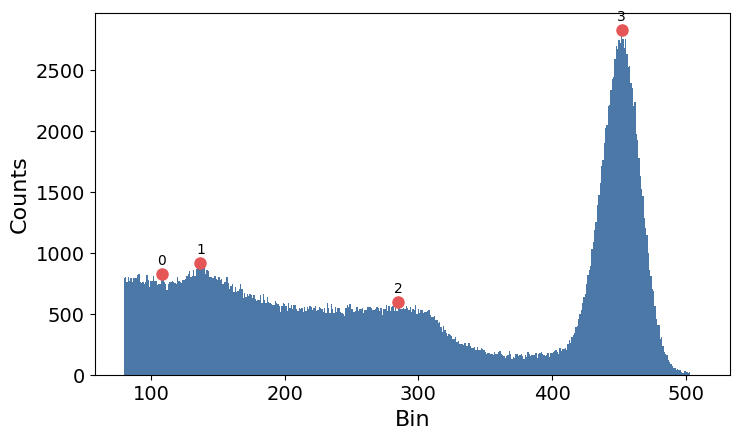

Selected candidate index (rightmost): 3
Candidate bin: 452.00
Fit success: True
mu = 452.108 +/- 0.100 bins
sigma = 13.968 +/- 0.156 bins
chi2/ndof = 56.78/56, p = 0.4459
N_fit_points = 61


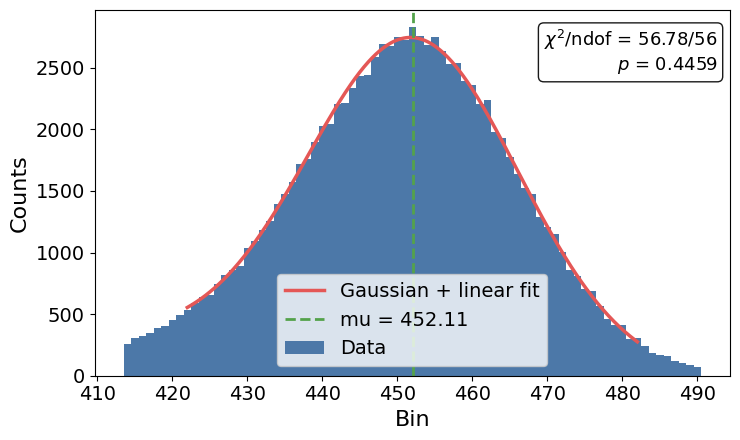

Peak rate = 328.356745 +/- 5.543223 counts/s
File: 03-12-Cs-137-scatter-0deg-2absorb.Spe
Raw channels: 2048
Rebin factor: 4
Channels used: 512
Live time [s]: 319.0
Real time [s]: 323.0


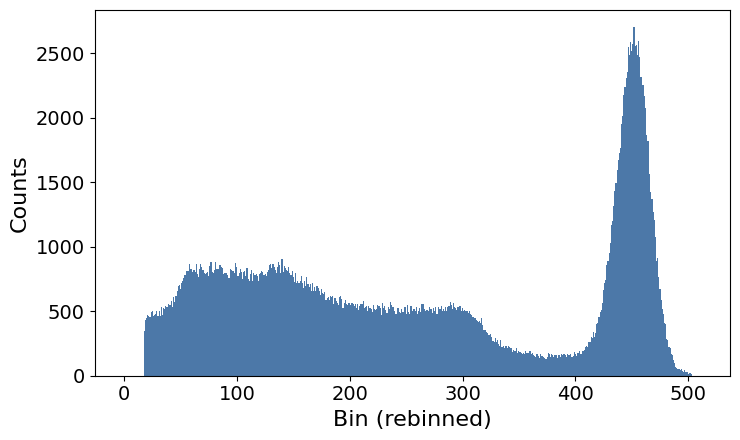

Candidate peaks:
[0] bin=109.0, height=831.0, prominence=83.0
[1] bin=140.0, height=907.0, prominence=176.0
[2] bin=162.0, height=765.0, prominence=84.0
[3] bin=236.0, height=570.0, prominence=96.0
[4] bin=264.0, height=558.0, prominence=81.0
[5] bin=289.0, height=569.0, prominence=94.0
[6] bin=452.0, height=2699.0, prominence=2571.0


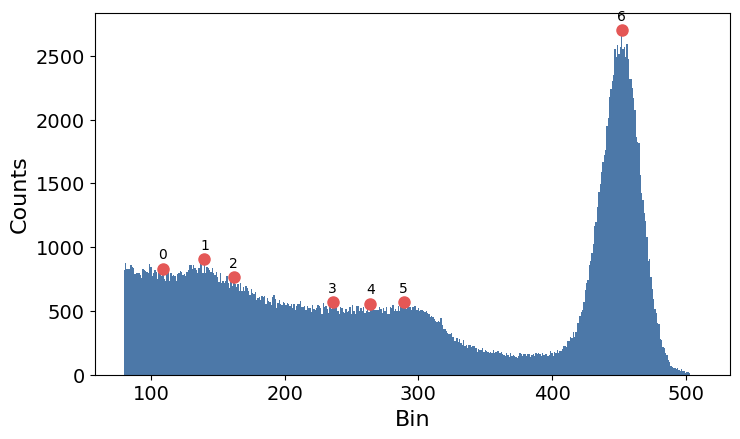

Selected candidate index (rightmost): 6
Candidate bin: 452.00
Fit success: True
mu = 452.199 +/- 0.104 bins
sigma = 14.168 +/- 0.165 bins
chi2/ndof = 81.91/56, p = 0.0136
N_fit_points = 61


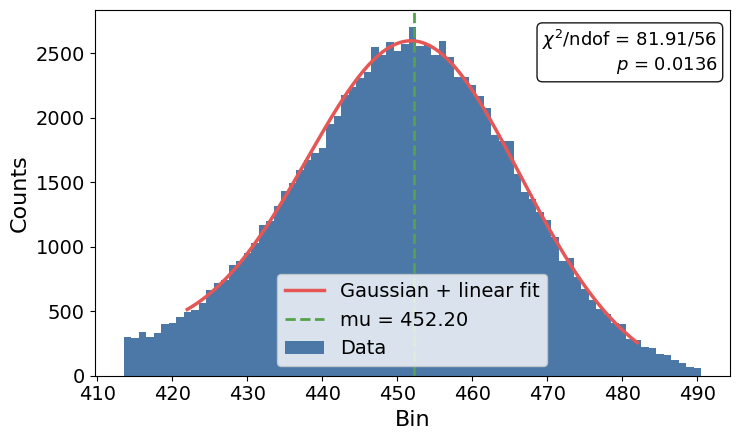

Peak rate = 275.414734 +/- 4.890529 counts/s
File: 03-12-Cs-137-scatter-0deg-3absorb.Spe
Raw channels: 2048
Rebin factor: 4
Channels used: 512
Live time [s]: 456.0
Real time [s]: 461.0


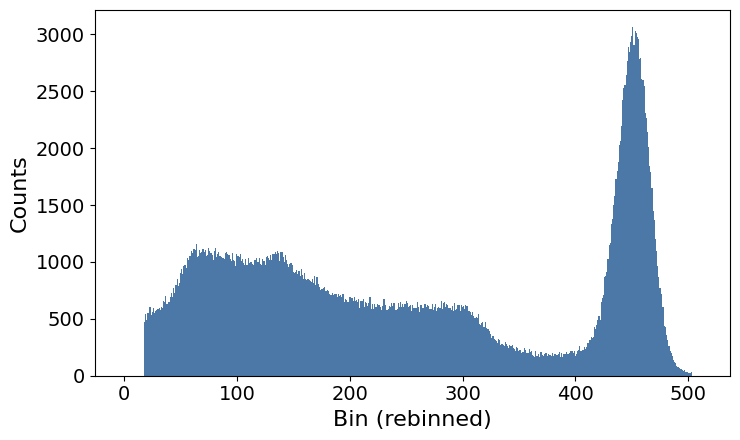

Candidate peaks:
[0] bin=103.0, height=1073.0, prominence=102.0
[1] bin=136.0, height=1094.0, prominence=129.0
[2] bin=230.0, height=678.0, prominence=96.0
[3] bin=281.0, height=654.0, prominence=95.0
[4] bin=451.0, height=3062.0, prominence=2900.0


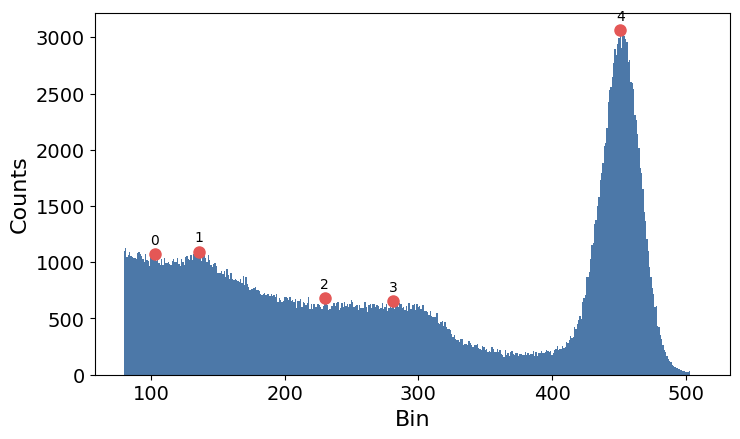

Selected candidate index (rightmost): 4
Candidate bin: 451.00
Fit success: True
mu = 452.286 +/- 0.098 bins
sigma = 14.274 +/- 0.156 bins
chi2/ndof = 87.54/56, p = 0.0045
N_fit_points = 61


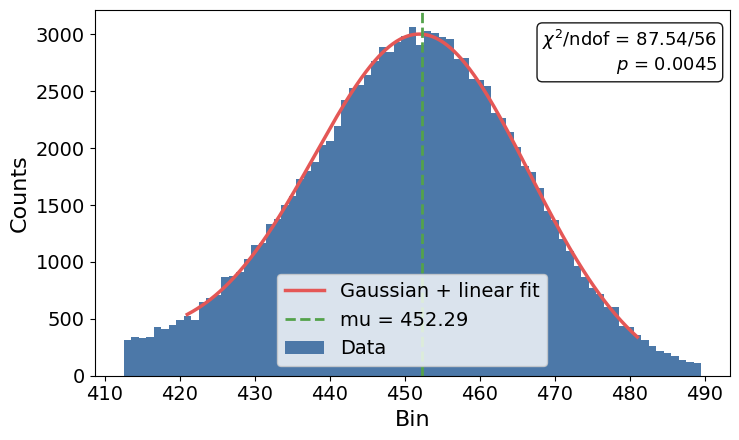

Peak rate = 226.876386 +/- 3.836056 counts/s
File: 03-12-Cs-137-scatter-0deg-4absorb.Spe
Raw channels: 2048
Rebin factor: 4
Channels used: 512
Live time [s]: 567.0
Real time [s]: 573.0


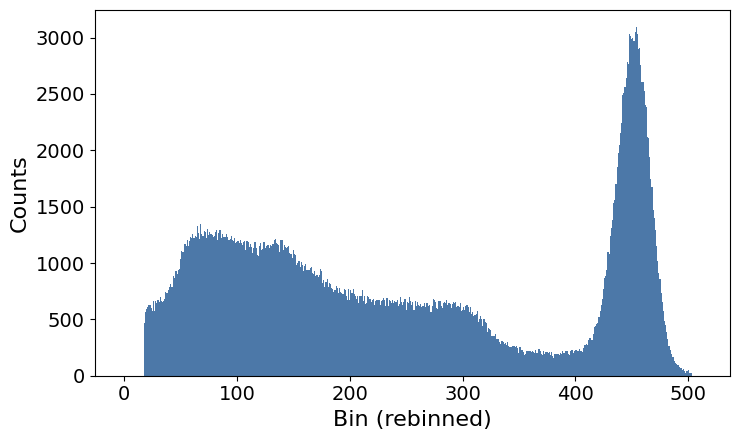

Candidate peaks:
[0] bin=134.0, height=1214.0, prominence=156.0
[1] bin=253.0, height=696.0, prominence=113.0
[2] bin=274.0, height=685.0, prominence=116.0
[3] bin=454.0, height=3090.0, prominence=2932.0


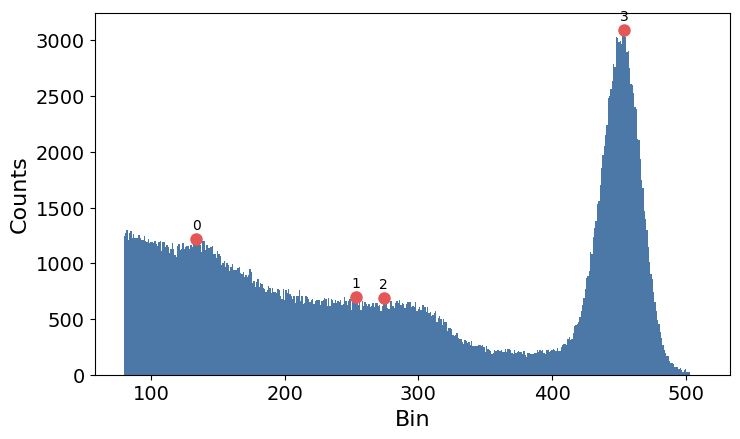

Selected candidate index (rightmost): 3
Candidate bin: 454.00
Fit success: True
mu = 452.523 +/- 0.101 bins
sigma = 14.053 +/- 0.152 bins
chi2/ndof = 55.99/56, p = 0.4752
N_fit_points = 61


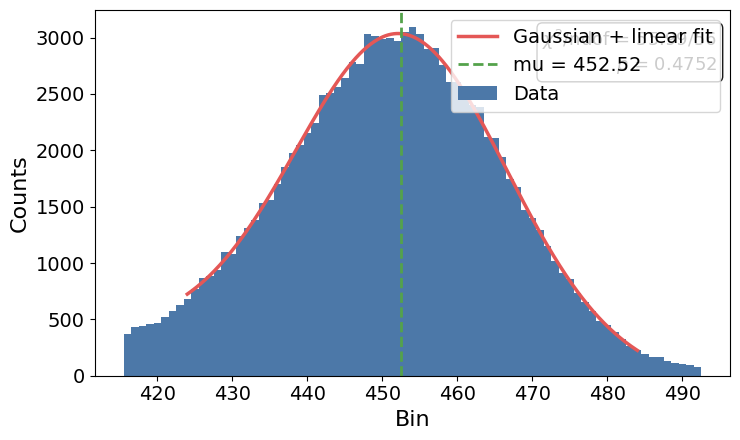

Peak rate = 176.977218 +/- 2.976568 counts/s
File: 03-12-Cs-137-scatter-0deg-5absorb.Spe
Raw channels: 2048
Rebin factor: 4
Channels used: 512
Live time [s]: 736.0
Real time [s]: 742.0


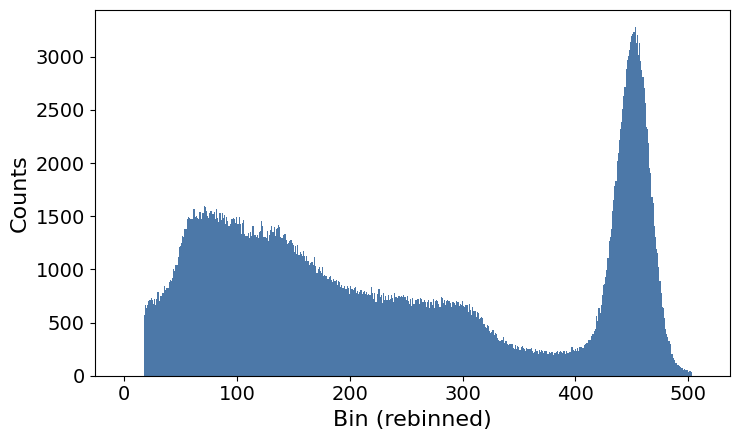

Candidate peaks:
[0] bin=122.0, height=1454.0, prominence=156.0
[1] bin=281.0, height=739.0, prominence=103.0
[2] bin=453.0, height=3276.0, prominence=3085.0


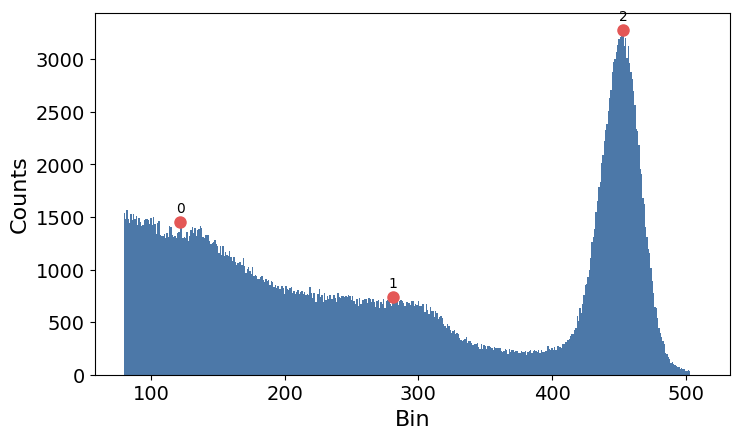

Selected candidate index (rightmost): 2
Candidate bin: 453.00
Fit success: True
mu = 452.273 +/- 0.097 bins
sigma = 14.163 +/- 0.152 bins
chi2/ndof = 62.04/56, p = 0.2697
N_fit_points = 61


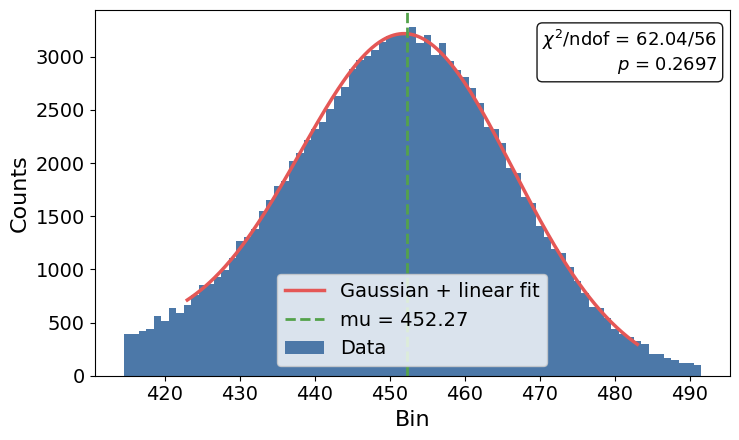

Peak rate = 146.231361 +/- 2.417167 counts/s

Summary (counts/s):
03-12-Cs-137-scatter-0deg-0absorb.Spe: 418.627806 +/- 7.721911
03-12-Cs-137-scatter-0deg-1absorb.Spe: 328.356745 +/- 5.543223
03-12-Cs-137-scatter-0deg-2absorb.Spe: 275.414734 +/- 4.890529
03-12-Cs-137-scatter-0deg-3absorb.Spe: 226.876386 +/- 3.836056
03-12-Cs-137-scatter-0deg-4absorb.Spe: 176.977218 +/- 2.976568
03-12-Cs-137-scatter-0deg-5absorb.Spe: 146.231361 +/- 2.417167


In [9]:
# Files from your screenshot
filenames = [
    "03-12-Cs-137-scatter-0deg-0absorb.Spe",
    "03-12-Cs-137-scatter-0deg-1absorb.Spe",
    "03-12-Cs-137-scatter-0deg-2absorb.Spe",
    "03-12-Cs-137-scatter-0deg-3absorb.Spe",
    "03-12-Cs-137-scatter-0deg-4absorb.Spe",
    "03-12-Cs-137-scatter-0deg-5absorb.Spe",
]

results = []
for fn in filenames:
    res = analyze_file(fn)
    results.append(res)

print("\nSummary (counts/s):")
for r in results:
    print(f"{r['filename']}: {r['rate_cps']:.6f} +/- {r['rate_err_cps']:.6f}")

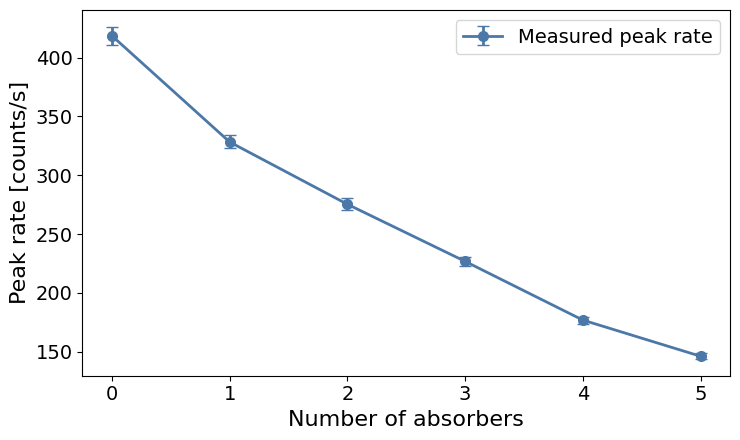

In [10]:
# Plot peak rate vs number of absorbers
absorber_counts = []
rates = []
rate_errs = []

for r in results:
    fname = r["filename"]
    # Expected pattern: ...-<N>absorb.Spe
    token = fname.split("-")[-1]  # e.g. "3absorb.Spe"
    n_abs = int(token.replace("absorb.Spe", ""))

    absorber_counts.append(n_abs)
    rates.append(r["rate_cps"])
    rate_errs.append(r["rate_err_cps"])

absorber_counts = np.array(absorber_counts, dtype=int)
rates = np.array(rates, dtype=float)
rate_errs = np.array(rate_errs, dtype=float)

order = np.argsort(absorber_counts)
absorber_counts = absorber_counts[order]
rates = rates[order]
rate_errs = rate_errs[order]

plt.figure()
plt.errorbar(
    absorber_counts,
    rates,
    yerr=rate_errs,
    fmt="o-",
    color="#4C78A8",
    ecolor="#4C78A8",
    capsize=4,
    lw=2,
    ms=7,
    label="Measured peak rate",
)
plt.xlabel("Number of absorbers")
plt.ylabel("Peak rate [counts/s]")
plt.xticks(absorber_counts)
plt.legend()
plt.tight_layout()
plt.show()

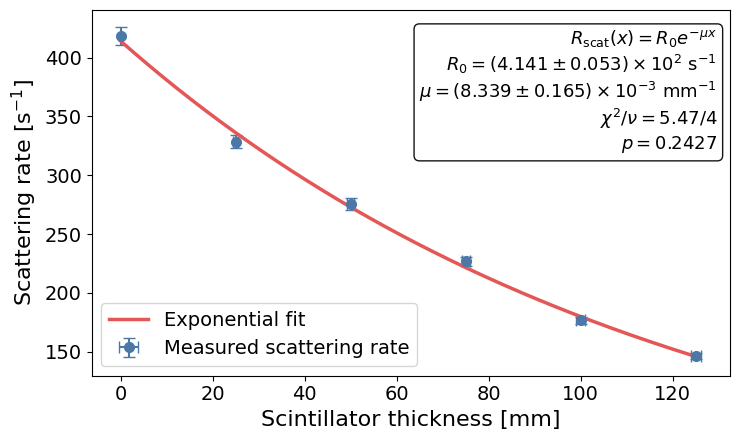

Exponential attenuation fit results (scattering rate model)
R0 = 414.111654 +/- 5.308247 s^-1
mu = 0.00833851 +/- 0.00016511 mm^-1
chi2/ndof = 5.466/4, p = 0.24272


In [11]:
# Peak rate vs scintillator thickness + exponential attenuation fit
from scipy.optimize import curve_fit
from scipy.stats import chi2


def attenuation_model(x_mm, I0, mu_mm_inv):
    return I0 * np.exp(-mu_mm_inv * x_mm)


# Build thickness axis from absorber count
thickness_per_abs_mm = 25.0
thickness_per_abs_err_mm = 0.5

thickness_mm = absorber_counts.astype(float) * thickness_per_abs_mm

# If each plate has independent +/-0.5 mm uncertainty, quadrature gives sqrt(N)*0.5.
# (If this is systematic instead, treat it separately and do not combine in quadrature.)
thickness_err_mm = np.sqrt(absorber_counts.astype(float)) * thickness_per_abs_err_mm

# Fit uses y-errors (rate uncertainties) as weights.
valid = np.isfinite(rates) & np.isfinite(rate_errs) & (rate_errs > 0)
x = thickness_mm[valid]
y = rates[valid]
yerr = rate_errs[valid]
xerr = thickness_err_mm[valid]

if len(x) < 2:
    raise ValueError("Need at least 2 valid points for attenuation fit")

p0 = [float(np.max(y)), 0.01]  # rough initial guess
popt, pcov = curve_fit(
    attenuation_model,
    x,
    y,
    p0=p0,
    sigma=yerr,
    absolute_sigma=True,
    maxfev=20000,
)
I0_fit, mu_fit = popt
perr = np.sqrt(np.diag(pcov))

yfit = attenuation_model(x, *popt)
chi2_val = float(np.sum(((y - yfit) / yerr) ** 2))
ndof = int(len(y) - len(popt))
p_value = float(chi2.sf(chi2_val, ndof)) if ndof > 0 else np.nan

# Smooth curve for display
xdense = np.linspace(float(np.min(x)), float(np.max(x)), 400)
ydense = attenuation_model(xdense, *popt)

plt.figure()
plt.errorbar(
    x,
    y,
    xerr=xerr,
    yerr=yerr,
    fmt="o",
    color="#4C78A8",
    ecolor="#4C78A8",
    capsize=4,
    ms=7,
    label="Measured scattering rate",
)
plt.plot(xdense, ydense, color="#E45756", lw=2.5, label="Exponential fit")
plt.xlabel("Scintillator thickness [mm]")
plt.ylabel("Scattering rate [s$^{-1}$]")


def value_pm_err_shared_exp_latex(v, verr, digits=3):
    """Format as (a ± b) x 10^n with shared exponent."""
    if (not np.isfinite(v)) or (not np.isfinite(verr)):
        return r"\mathrm{nan}"
    if v == 0:
        return f"(0.000\\pm{verr:.{digits}g})"
    exp = int(np.floor(np.log10(abs(v))))
    scale = 10 ** exp
    mant = v / scale
    mant_err = verr / scale
    return rf"({mant:.{digits}f}\pm{mant_err:.{digits}f})\times10^{{{exp}}}"


R0_pm = value_pm_err_shared_exp_latex(I0_fit, perr[0], digits=3)
mu_pm = value_pm_err_shared_exp_latex(mu_fit, perr[1], digits=3)

textbox = "\n".join([
    r"$R_{\mathrm{scat}}(x)=R_0 e^{-\mu x}$",
    rf"$R_0={R0_pm}\ \mathrm{{s^{{-1}}}}$",
    rf"$\mu={mu_pm}\ \mathrm{{mm^{{-1}}}}$",
    rf"$\chi^2/\nu = {chi2_val:.2f}/{ndof}$",
    rf"$p = {p_value:.4f}$",
])

plt.text(
    0.98,
    0.95,
    textbox,
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    fontsize=13,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.92, edgecolor="black"),
)

plt.legend()
plt.tight_layout()
plt.show()

print("Exponential attenuation fit results (scattering rate model)")
print(f"R0 = {I0_fit:.6f} +/- {perr[0]:.6f} s^-1")
print(f"mu = {mu_fit:.8f} +/- {perr[1]:.8f} mm^-1")
print(f"chi2/ndof = {chi2_val:.3f}/{ndof}, p = {p_value:.5f}")